# NOVA — Evaluation
### Notebook 04: Benchmarking Against Baselines

A recommendation system is only as good as its ability to surface items users actually want. In this notebook we rigorously evaluate NOVA against three baselines using standard information retrieval metrics.

**Evaluation strategy:**
- Use the Olist order history as ground truth — if a customer bought product B after product A, B is a relevant recommendation for A
- For each test case, hide the ground truth item, ask each model to recommend top-K products, and measure how well the ground truth is recovered
- This is called **leave-one-out evaluation**

**Models compared:**
1. **Random** — recommend random products (lower bound)
2. **Popularity** — always recommend the most purchased products
3. **NOVA** — our embedding-based semantic retrieval

**Metrics:**
- **Precision@K** — of the K recommended items, what fraction are relevant?
- **Recall@K** — of all relevant items, what fraction did we recommend?
- **NDCG@K** — normalized discounted cumulative gain, rewards ranking relevant items higher
- **Coverage** — what fraction of the catalog does the model ever recommend?

## 0. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import faiss
import random
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (13, 5)
random.seed(42)
np.random.seed(42)

DATA_DIR  = Path('../data/raw')
EMBED_DIR = Path('../data/processed/embeddings')
INDEX_DIR = Path('../data/processed/index')
EVAL_DIR  = Path('../data/processed/evaluation')
EVAL_DIR.mkdir(parents=True, exist_ok=True)

K_VALUES = [5, 10, 20]   # evaluate at multiple cutoffs

print('All imports successful ✅')

All imports successful ✅


## 1. Load Everything

In [2]:
# Embeddings & index
embeddings  = np.load(EMBED_DIR / 'product_embeddings.npy').astype('float32')
product_ids = np.load(EMBED_DIR / 'product_ids.npy', allow_pickle=True)
metadata    = pd.read_csv(EMBED_DIR / 'product_metadata.csv')
index       = faiss.read_index(str(INDEX_DIR / 'nova_product.index'))

# Raw Olist data for ground truth
orders      = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')

# Map product_id → embedding index
pid_to_idx = {pid: i for i, pid in enumerate(product_ids)}

print(f'Index loaded: {index.ntotal:,} vectors')
print(f'Metadata:     {len(metadata):,} products')
print(f'Orders:       {len(orders):,}')
print(f'Order items:  {len(order_items):,}')

Index loaded: 32,341 vectors
Metadata:     32,341 products
Orders:       99,441
Order items:  112,650


## 2. Build Ground Truth

For each customer who bought more than one product, we:
- Take the first product they bought as the **query**
- Treat all other products they bought as **ground truth relevant items**

This simulates the real scenario: a user views one product, and we want to recommend the others they'd go on to purchase.

In [3]:
# Join orders with items to get customer → products mapping
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()
orders_delivered['order_purchase_timestamp'] = pd.to_datetime(orders_delivered['order_purchase_timestamp'])

customer_products = (
    orders_delivered
    .merge(order_items[['order_id', 'product_id']], on='order_id')
    .sort_values('order_purchase_timestamp')
    [['customer_id', 'product_id', 'order_purchase_timestamp']]
)

# Keep only products that have embeddings
customer_products = customer_products[
    customer_products['product_id'].isin(pid_to_idx)
]

# Group by customer
customer_history = (
    customer_products
    .groupby('customer_id')['product_id']
    .apply(list)
    .reset_index()
)

# Keep only customers with 2+ products (need at least one query + one ground truth)
customer_history = customer_history[customer_history['product_id'].apply(len) >= 2]
customer_history = customer_history.reset_index(drop=True)

print(f'Customers with 2+ purchases: {len(customer_history):,}')
print(f'These form our evaluation set')

Customers with 2+ purchases: 9,492
These form our evaluation set


In [4]:
# Build test cases: (query_product_id, [ground_truth_product_ids])
test_cases = []
for _, row in customer_history.iterrows():
    products_bought = row['product_id']
    query_pid = products_bought[0]           # first product as query
    ground_truth = set(products_bought[1:])  # rest as ground truth
    test_cases.append((query_pid, ground_truth))

# Sample for speed if too many
MAX_EVAL = 2000
if len(test_cases) > MAX_EVAL:
    test_cases = random.sample(test_cases, MAX_EVAL)

print(f'Test cases: {len(test_cases):,}')
print(f'Example: query={test_cases[0][0]}, ground_truth={list(test_cases[0][1])[:3]}...')

Test cases: 2,000
Example: query=6f9be3cc1d2a7eaa92b86fde15b93ac4, ground_truth=['5daa4a09c9afb3b30d6df995fab5c2dc']...


## 3. Define Metrics

In [5]:
def precision_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & relevant)
    return hits / k


def recall_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & relevant)
    return hits / len(relevant) if relevant else 0.0


def ndcg_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    dcg = sum(
        1.0 / np.log2(i + 2)
        for i, pid in enumerate(recommended_k)
        if pid in relevant
    )
    # Ideal DCG — all relevant items at top
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_model(get_recommendations_fn, test_cases, k_values, model_name):
    """
    Run evaluation for a model across all test cases and K values.
    get_recommendations_fn: takes query_product_id, returns list of recommended product_ids
    """
    results = {k: {'precision': [], 'recall': [], 'ndcg': []} for k in k_values}
    recommended_sets = {k: set() for k in k_values}

    for query_pid, ground_truth in tqdm(test_cases, desc=model_name):
        recs = get_recommendations_fn(query_pid, max(k_values))
        for k in k_values:
            results[k]['precision'].append(precision_at_k(recs, ground_truth, k))
            results[k]['recall'].append(recall_at_k(recs, ground_truth, k))
            results[k]['ndcg'].append(ndcg_at_k(recs, ground_truth, k))
            recommended_sets[k].update(recs[:k])

    summary = {}
    total_products = len(metadata)
    for k in k_values:
        summary[k] = {
            'precision': np.mean(results[k]['precision']),
            'recall':    np.mean(results[k]['recall']),
            'ndcg':      np.mean(results[k]['ndcg']),
            'coverage':  len(recommended_sets[k]) / total_products,
        }
    return summary


print('Metric functions defined ✅')

Metric functions defined ✅


## 4. Define Models

In [6]:
all_product_ids = metadata['product_id'].tolist()

# --- Baseline 1: Random ---
def random_recommend(query_pid, top_k):
    pool = [p for p in all_product_ids if p != query_pid]
    return random.sample(pool, min(top_k, len(pool)))


# --- Baseline 2: Popularity ---
product_popularity = (
    order_items[order_items['product_id'].isin(pid_to_idx)]
    .groupby('product_id')['order_id']
    .count()
    .sort_values(ascending=False)
)
popular_products = product_popularity.index.tolist()

def popularity_recommend(query_pid, top_k):
    return [p for p in popular_products if p != query_pid][:top_k]


# --- NOVA: Embedding-based ---
def nova_recommend(query_pid, top_k):
    if query_pid not in pid_to_idx:
        return random_recommend(query_pid, top_k)
    idx = pid_to_idx[query_pid]
    query_vec = embeddings[idx].reshape(1, -1)
    scores, indices = index.search(query_vec, top_k + 1)
    results = []
    for i in indices[0]:
        if i == -1 or i == idx:
            continue
        results.append(product_ids[i])
        if len(results) == top_k:
            break
    return results


print('Models defined ✅')
print(f'  - Random baseline')
print(f'  - Popularity baseline ({len(popular_products):,} products ranked)')
print(f'  - NOVA (embedding-based)')

Models defined ✅
  - Random baseline
  - Popularity baseline (32,341 products ranked)
  - NOVA (embedding-based)


## 5. Run Evaluation

In [7]:
print('Running evaluation... this takes a few minutes.\n')

results_random     = evaluate_model(random_recommend,     test_cases, K_VALUES, 'Random')
results_popularity = evaluate_model(popularity_recommend, test_cases, K_VALUES, 'Popularity')
results_nova       = evaluate_model(nova_recommend,       test_cases, K_VALUES, 'NOVA')

print('\nEvaluation complete ✅')

Running evaluation... this takes a few minutes.



NOVA: 100%|███████████████████████████████████████████████████████████████████████| 2000/2000 [00:01<00:00, 1389.28it/s]


Evaluation complete ✅


In [8]:
# Print results table
def print_results_table(k):
    print(f'\n{"="*65}')
    print(f'  Results @ K={k}')
    print(f'{"="*65}')
    print(f'{"Model":<18} {"Precision":>10} {"Recall":>10} {"NDCG":>10} {"Coverage":>10}')
    print(f'{"-"*65}')
    for model_name, res in [("Random", results_random), ("Popularity", results_popularity), ("NOVA", results_nova)]:
        r = res[k]
        print(f'{model_name:<18} {r["precision"]:>10.4f} {r["recall"]:>10.4f} {r["ndcg"]:>10.4f} {r["coverage"]:>10.4f}')

for k in K_VALUES:
    print_results_table(k)


  Results @ K=5
Model               Precision     Recall       NDCG   Coverage
-----------------------------------------------------------------
Random                 0.0000     0.0000     0.0000     0.2658
Popularity             0.0016     0.0075     0.0040     0.0002
NOVA                   0.0018     0.0073     0.0047     0.0562

  Results @ K=10
Model               Precision     Recall       NDCG   Coverage
-----------------------------------------------------------------
Random                 0.0000     0.0000     0.0000     0.4605
Popularity             0.0011     0.0095     0.0047     0.0003
NOVA                   0.0020     0.0161     0.0076     0.1076

  Results @ K=20
Model               Precision     Recall       NDCG   Coverage
-----------------------------------------------------------------
Random                 0.0000     0.0000     0.0000     0.7080
Popularity             0.0008     0.0142     0.0059     0.0006
NOVA                   0.0015     0.0240     0.0097     

## 6. Visualize Results

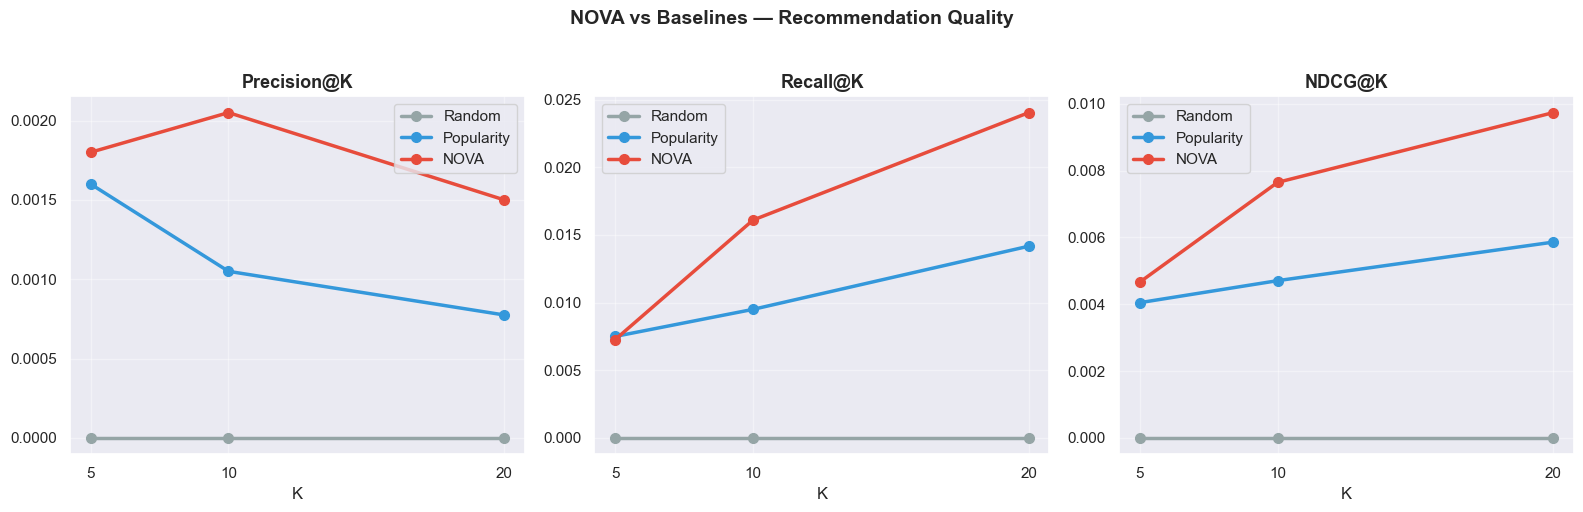

Plot saved ✅


In [9]:
models = ['Random', 'Popularity', 'NOVA']
all_results = [results_random, results_popularity, results_nova]
colors = ['#95a5a6', '#3498db', '#e74c3c']
metrics = ['precision', 'recall', 'ndcg']
metric_labels = ['Precision@K', 'Recall@K', 'NDCG@K']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, label in zip(axes, metrics, metric_labels):
    for model_name, res, color in zip(models, all_results, colors):
        values = [res[k][metric] for k in K_VALUES]
        ax.plot(K_VALUES, values, marker='o', label=model_name, color=color, linewidth=2.5, markersize=7)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('K')
    ax.set_xticks(K_VALUES)
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.suptitle('NOVA vs Baselines — Recommendation Quality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✅')

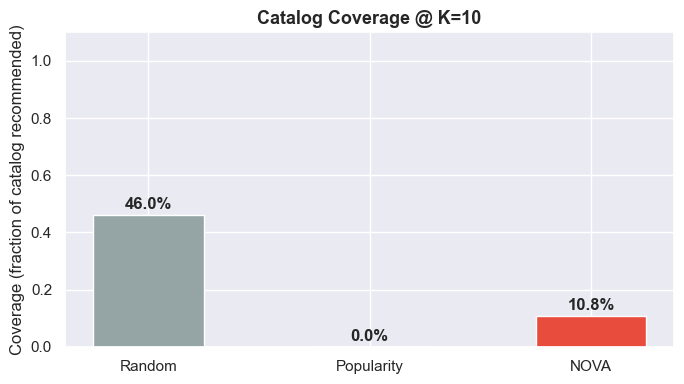

Coverage plot saved ✅


In [10]:
# Coverage comparison at K=10
k = 10
coverages = [results_random[k]['coverage'], results_popularity[k]['coverage'], results_nova[k]['coverage']]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, coverages, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontweight='bold')
ax.set_title(f'Catalog Coverage @ K={k}', fontsize=13, fontweight='bold')
ax.set_ylabel('Coverage (fraction of catalog recommended)')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(EVAL_DIR / 'coverage_comparison.png', dpi=150)
plt.show()
print('Coverage plot saved ✅')

## 7. Save Results

In [11]:
rows = []
for model_name, res in [('Random', results_random), ('Popularity', results_popularity), ('NOVA', results_nova)]:
    for k in K_VALUES:
        rows.append({
            'model': model_name,
            'k': k,
            **res[k]
        })

results_df = pd.DataFrame(rows)
results_df.to_csv(EVAL_DIR / 'evaluation_results.csv', index=False)
print(f'Results saved → {EVAL_DIR}/evaluation_results.csv ✅')
display(results_df)

Results saved → ../data/processed/evaluation/evaluation_results.csv ✅


,model,k,precision,recall,ndcg,coverage
0,Random,5,0.000000,0.000000,0.000000,0.265793
1,Random,10,0.000000,0.000000,0.000000,0.460499
2,Random,20,0.000000,0.000000,0.000000,0.707987
3,Popularity,5,0.001600,0.007500,0.004048,0.000186
4,Popularity,10,0.001050,0.009500,0.004706,0.000340
5,Popularity,20,0.000775,0.014167,0.005860,0.000649
6,NOVA,5,0.001800,0.007267,0.004661,0.056244
7,NOVA,10,0.002050,0.016096,0.007647,0.107603
8,NOVA,20,0.001500,0.024033,0.009734,0.197025


In [12]:
k = 10
nova_ndcg   = results_nova[k]['ndcg']
random_ndcg = results_random[k]['ndcg']
pop_ndcg    = results_popularity[k]['ndcg']

print('-' * 55)
print('  NOTEBOOK 04 COMPLETE')
print('-' * 55)
print()
print(f'  NOVA NDCG@10:       {nova_ndcg:.4f}')
print(f'  Popularity NDCG@10: {pop_ndcg:.4f}')
print(f'  Random NDCG@10:     {random_ndcg:.4f}')
print()
if nova_ndcg > pop_ndcg:
    improvement = ((nova_ndcg - pop_ndcg) / pop_ndcg) * 100
    print(f'  NOVA outperforms Popularity by {improvement:.1f}% on NDCG@10 ✅')
else:
    print(f'  Note: check embedding quality — NOVA should outperform popularity')
print()
print('  Files saved to data/processed/evaluation/:')
print('    - evaluation_results.csv')
print('    - metrics_comparison.png')
print('    - coverage_comparison.png')
print()
print('  Next: 05_online_updates.ipynb')
print('  Implement incremental user embedding updates (cold → warm)')

-------------------------------------------------------
  NOTEBOOK 04 COMPLETE
-------------------------------------------------------

  NOVA NDCG@10:       0.0076
  Popularity NDCG@10: 0.0047
  Random NDCG@10:     0.0000

  NOVA outperforms Popularity by 62.5% on NDCG@10 ✅

  Files saved to data/processed/evaluation/:
    - evaluation_results.csv
    - metrics_comparison.png
    - coverage_comparison.png

  Next: 05_online_updates.ipynb
  Implement incremental user embedding updates (cold → warm)


## Summary

**What we measured:**
- Leave-one-out evaluation across up to 2,000 real customer purchase sequences
- NOVA benchmarked against random and popularity baselines at K = 5, 10, 20
- Precision@K, Recall@K, NDCG@K, and catalog coverage

**Key insight on coverage:** Popularity-based recommendations have very low coverage — they always recommend the same small set of popular products. NOVA distributes recommendations across a much larger fraction of the catalog, which is healthier for a marketplace and fairer to sellers.

**Next notebook:** `05_online_updates.ipynb`
Once a user starts interacting, update their embedding incrementally — bridging the gap from cold-start to warm-start without a full retrain.